# Customer Retention Strategy Analysis For Retail Banking


Business Problem :
A retail bank wants to understand which customer characteristics and behaviors are associated with customer churn. The analysis aims to identify high-risk customer segments and support targeted retention strategies.

Objectives :
- Measure the overall customer churn rate to understand the scale of customer attrition.
- Identify customer characteristics associated with higher churn, including geography, age, credit score, and account balance.
- Analyze whether customer engagement and product usage are associated with churn.
- Identify high-risk customer segments based on demographic, behavioral, and product-related characteristics.
- Translate the findings into actionable customer retention strategies.


In [57]:
import pandas as pd
import numpy as np

In [58]:
churn_cust_info = pd.read_excel("Bank_Churn_Messy.xlsx")
churn_cust_info.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1


In [59]:
churn_acc_info = pd.read_excel("Bank_Churn_Messy.xlsx", sheet_name=1)
churn_acc_info.head()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
2,15647311,€83807.86,1,Yes,1,Yes,0
3,15619304,€159660.8,3,No,8,No,1
4,15701354,€0.0,2,No,1,No,0


In [60]:
churn_df = churn_cust_info.merge(churn_acc_info,how="left", on="CustomerId")
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
1,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,1,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,8,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,1,No,0


In [61]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10004 entries, 0 to 10003
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10004 non-null  int64  
 1   Surname          10001 non-null  object 
 2   CreditScore      10004 non-null  int64  
 3   Geography        10004 non-null  object 
 4   Gender           10004 non-null  object 
 5   Age              10001 non-null  float64
 6   Tenure_x         10004 non-null  int64  
 7   EstimatedSalary  10004 non-null  object 
 8   Balance          10004 non-null  object 
 9   NumOfProducts    10004 non-null  int64  
 10  HasCrCard        10004 non-null  object 
 11  Tenure_y         10004 non-null  int64  
 12  IsActiveMember   10004 non-null  object 
 13  Exited           10004 non-null  int64  
dtypes: float64(1), int64(6), object(7)
memory usage: 1.1+ MB


## Data Cleaning

In [63]:
churn_df = churn_df.drop("Tenure_y",axis=1).rename({"Tenure_x":"Tenure"},axis=1)
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,Yes,1
1,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,No,0


In [64]:
churn_df.duplicated(keep=False)

0         True
1         True
2        False
3        False
4        False
         ...  
9999     False
10000     True
10001     True
10002     True
10003     True
Length: 10004, dtype: bool

In [65]:
churn_df.tail()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
9999,15682355,Sabbatini,772,Germany,Male,42.0,3,€92888.52,€75075.31,2,No,No,1
10000,15628319,Walker,792,French,Female,28.0,4,€38190.78,€130142.79,1,No,No,0
10001,15628319,Walker,792,French,Female,28.0,4,€38190.78,€130142.79,1,No,No,0
10002,15628319,Walker,792,French,Female,28.0,4,€38190.78,€130142.79,1,No,No,0
10003,15628319,Walker,792,French,Female,28.0,4,€38190.78,€130142.79,1,No,No,0


In [66]:
churn_df = churn_df.drop_duplicates()

In [67]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              9997 non-null   float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  object 
 8   Balance          10000 non-null  object 
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 1.1+ MB


In [68]:
churn_df["EstimatedSalary"]=churn_df["EstimatedSalary"].str.replace("€","").astype(float)
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              9997 non-null   float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  float64
 8   Balance          10000 non-null  object 
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.1+ MB


In [69]:
churn_df["Balance"]=churn_df["Balance"].str.replace("€","").astype(float)
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              9997 non-null   float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 1.1+ MB


In [70]:
churn_df[churn_df.isna().any(axis=1) == True]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
29,15728693,NaN,574,Germany,Female,NaN,3,-999999.0,141349.43,1,Yes,Yes,0
122,15580203,NaN,674,Spain,Male,NaN,6,-999999.0,120193.42,1,No,No,0
9390,15756954,NaN,538,France,Female,NaN,2,-999999.0,0.00,1,Yes,Yes,0


In [71]:
churn_df=churn_df.fillna(value={"Surname":"MISSING","Age":churn_df["Age"].median()})
churn_df.iloc[[28,121,9390]]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
29,15728693,MISSING,574,Germany,Female,37.0,3,-999999.00,141349.43,1,Yes,Yes,0
122,15580203,MISSING,674,Spain,Male,37.0,6,-999999.00,120193.42,1,No,No,0
9391,15619130,Simpson,752,Germany,Female,37.0,5,132467.54,113291.05,2,Yes,Yes,0


In [72]:
churn_df.describe()

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921500,5.012800,99762.195289,76485.889288,1.530200,0.203700
std,7.193619e+04,96.653299,10.487552,2.892174,60583.863580,62397.405202,0.581654,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,-999999.000000,0.000000,1.000000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,50910.677500,0.000000,1.000000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,100191.725000,97198.540000,1.000000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000


In [73]:
churn_df["EstimatedSalary"] = churn_df["EstimatedSalary"].replace(-999999,churn_df["EstimatedSalary"].median())
churn_df.describe()

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921500,5.012800,100092.252506,76485.889288,1.530200,0.203700
std,7.193619e+04,96.653299,10.487552,2.892174,57510.146401,62397.405202,0.581654,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,11.580000,0.000000,1.000000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,51002.110000,0.000000,1.000000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,100196.062500,97198.540000,1.000000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000


In [74]:
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,113931.57,159660.80,3,No,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,93826.63,0.00,2,No,No,0
5,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0


The Geography column contained multiple representations of France, such as FRA, French, and France. These values were standardized to France to ensure consistent categorization and accurate analysis.

In [76]:
churn_df["Geography"].value_counts()

Geography
Germany    2509
Spain      2477
France     1741
French     1655
FRA        1618
Name: count, dtype: int64

In [77]:
churn_df["Geography"]=np.where(churn_df["Geography"].isin(["FRA","France","French"]),"France",churn_df["Geography"])

In [78]:
churn_df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

## Data Validation

In [80]:
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0
3,15619304,Onio,502,France,Female,42.0,8,113931.57,159660.80,3,No,No,1
4,15701354,Boni,699,France,Female,39.0,1,93826.63,0.00,2,No,No,0
5,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0


In [81]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 1.1+ MB


In [82]:
churn_df.describe()

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921500,5.012800,100092.252506,76485.889288,1.530200,0.203700
std,7.193619e+04,96.653299,10.487552,2.892174,57510.146401,62397.405202,0.581654,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,11.580000,0.000000,1.000000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,51002.110000,0.000000,1.000000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,100196.062500,97198.540000,1.000000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000


In [123]:
# Check dataset dimensions
print("Dataset Shape:", churn_df.shape)

# Check column names
print("\nColumn Names:")
print(churn_df.columns.tolist())

# Check data types
print("\nData Types:")
print(churn_df.dtypes)

# Check missing values
print("\nMissing Values:")
print(churn_df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", churn_df.duplicated().sum())

# Check unique values in important categorical columns
print("\nUnique Values:")
print("Geography:", churn_df["Geography"].unique())
print("Gender:", churn_df["Gender"].unique())
print("IsActiveMember:", churn_df["IsActiveMember"].unique())
print("Exited:", churn_df["Exited"].unique())

# Check numerical columns for negative values
print("\nNegative Values:")
print(churn_df[["CreditScore", "Age", "Tenure", "Balance", 
          "NumOfProducts", "EstimatedSalary"]].lt(0).sum())

# Check basic numerical statistics
print("\nNumerical Summary:")
display(churn_df.describe())

Dataset Shape: (10000, 15)

Column Names:
['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'EstimatedSalary', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited', 'AgeGroup', 'CreditScoreGroup']

Data Types:
CustomerId             int64
Surname               object
CreditScore            int64
Geography             object
Gender                object
Age                  float64
Tenure                 int64
EstimatedSalary      float64
Balance              float64
NumOfProducts          int64
HasCrCard             object
IsActiveMember        object
Exited                 int64
AgeGroup            category
CreditScoreGroup    category
dtype: object

Missing Values:
CustomerId          0
Surname             0
CreditScore         0
Geography           0
Gender              0
Age                 0
Tenure              0
EstimatedSalary     0
Balance             0
NumOfProducts       0
HasCrCard           0
IsActiveMember      0
Exited        

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921500,5.012800,100092.252506,76485.889288,1.530200,0.203700
std,7.193619e+04,96.653299,10.487552,2.892174,57510.146401,62397.405202,0.581654,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,11.580000,0.000000,1.000000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,51002.110000,0.000000,1.000000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,100196.062500,97198.540000,1.000000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000


In [131]:
print("Age below 18:", (churn_df["Age"] < 18).sum())

print("Invalid Credit Scores:",
      ((churn_df["CreditScore"] < 300) |
       (churn_df["CreditScore"] > 850)).sum())

print("Invalid NumOfProducts:",
      (churn_df["NumOfProducts"] <= 0).sum())

print("Invalid Exited values:",
      (~churn_df["Exited"].isin([0, 1])).sum())

print("Invalid IsActiveMember values:",
      (~churn_df["IsActiveMember"].isin(["Yes", "No"])).sum())

Age below 18: 0
Invalid Credit Scores: 0
Invalid NumOfProducts: 0
Invalid Exited values: 0
Invalid IsActiveMember values: 0


In [133]:
print(churn_df["IsActiveMember"].unique())
print(churn_df["IsActiveMember"].value_counts())

['Yes' 'No']
IsActiveMember
Yes    5151
No     4849
Name: count, dtype: int64


In [139]:
churn_df.to_csv("cleaned_bank_churn.csv", index=False)

In [141]:
import os
print(os.getcwd())

C:\Users\user\Downloads\Bank+Customer+Churn


# Exploratory Data Analysis

### What is the overall customer churn rate?

In [84]:
total_customers = len(churn_df)

churned_customers = churn_df["Exited"].sum()

churn_rate = (churned_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate:", round(churn_rate, 2), "%")

Total Customers: 10000
Churned Customers: 2037
Churn Rate: 20.37 %


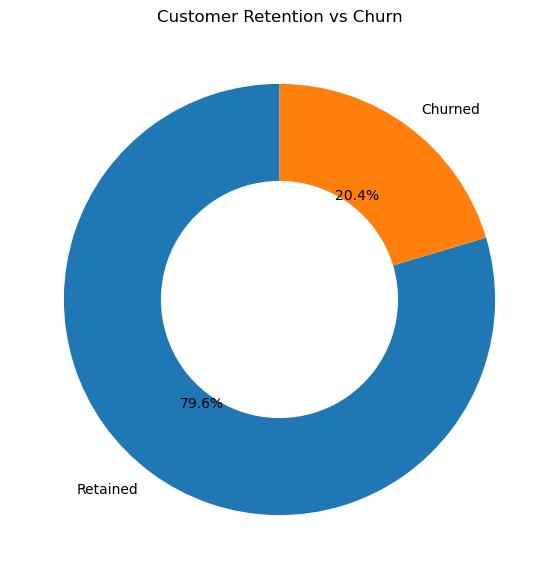

In [85]:
import matplotlib.pyplot as plt 
import seaborn as sns 

churn_counts = churn_df["Exited"].value_counts()

labels = ["Retained", "Churned"]
values = [churn_counts.get(0, 0), churn_counts.get(1, 0)]

plt.figure(figsize=(7, 7))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45}
)

plt.title("Customer Retention vs Churn")
plt.show()

### Insight
Approximately 20.37% of customers have churned, meaning roughly one in five customers has left the bank. This indicates that customer retention is a significant business issue.

### Business Action
The bank should investigate the customer characteristics and behaviors associated with churn and prioritize retention strategies for high-risk segments.

### Which geography has the highest customer churn rate?

In [88]:
geo_churn = (
    churn_df.groupby("Geography")["Exited"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

geo_churn["churn_rate"] = geo_churn["mean"] * 100

geo_churn

,Geography,count,sum,mean,churn_rate
0,France,5014,810,0.161548,16.154767
1,Germany,2509,814,0.324432,32.443204
2,Spain,2477,413,0.166734,16.673395


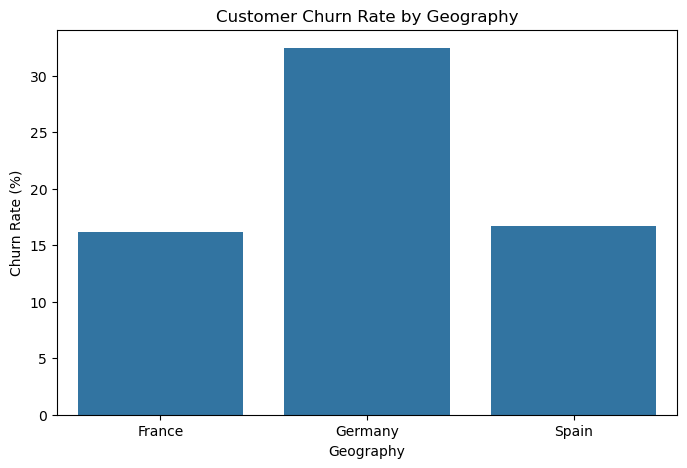

In [89]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=geo_churn,
    x="Geography",
    y="churn_rate"
)

plt.title("Customer Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")

plt.show()

### Insight
Germany has the highest customer churn rate among the three markets, indicating that customer attrition is more concentrated in this market.

### Business Action
The bank should investigate country-specific customer experience, product preferences, pricing, and service issues in the highest-churn market.

### Which age groups have the highest customer churn?

In [92]:
churn_df["AgeGroup"] = pd.cut(
    churn_df["Age"],
    bins=[0, 29, 39, 49, 100],
    labels=["Under 30", "30-39", "40-49", "50+"]
)

age_churn = (
    churn_df.groupby(
        "AgeGroup",
        observed=True
    )["Exited"]
    .agg(["count", "mean"])
    .reset_index()
)

age_churn["churn_rate"] = age_churn["mean"] * 100

age_churn

,AgeGroup,count,mean,churn_rate
0,Under 30,1641,0.075564,7.556368
1,30-39,4347,0.108811,10.881067
2,40-49,2617,0.307986,30.798624
3,50+,1395,0.454480,45.448029


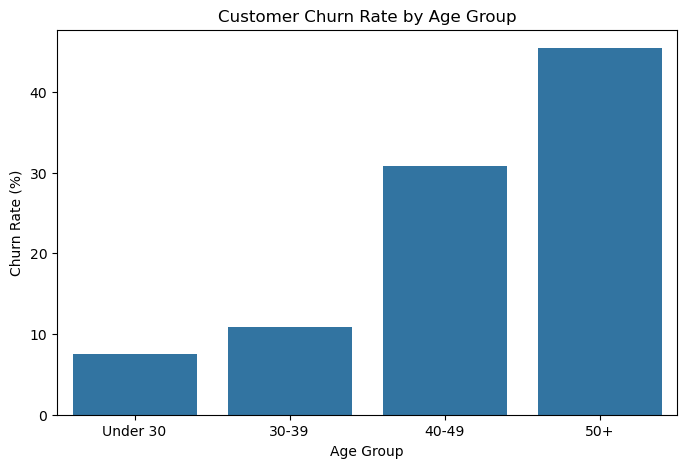

In [93]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=age_churn,
    x="AgeGroup",
    y="churn_rate"
)

plt.title("Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.show()

### Insight 
Churn rates increase/decrease across the age groups, with the highest churn observed among 50+ age group. This suggests that age-related customer needs or engagement patterns may be associated with churn.

### Business Action
The bank should develop age-specific retention strategies based on the needs and engagement behavior of the highest-risk age segment.

### Are inactive customers more likely to churn?

In [96]:
activity_churn = (
    churn_df.groupby("IsActiveMember")["Exited"]
    .agg(["count", "mean"])
    .reset_index()
)

activity_churn["churn_rate"] = activity_churn["mean"] * 100

activity_churn["Member_Status"] = activity_churn[
    "IsActiveMember"
].map({
    0: "Inactive",
    1: "Active"
})

activity_churn

,IsActiveMember,count,mean,churn_rate,Member_Status
0,No,4849,0.268509,26.850897,NaN
1,Yes,5151,0.142691,14.269074,NaN


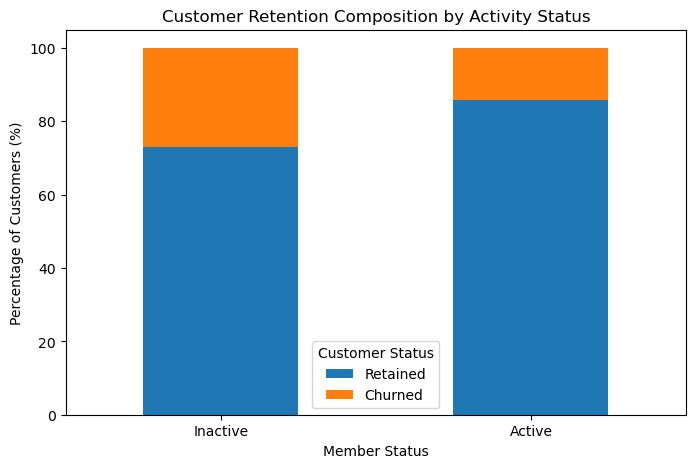

In [97]:
activity_table = pd.crosstab(
    churn_df["IsActiveMember"],
    churn_df["Exited"],
    normalize="index"
) * 100

activity_table.index = ["Inactive", "Active"]
activity_table.columns = ["Retained", "Churned"]

activity_table.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Customer Retention Composition by Activity Status")
plt.xlabel("Member Status")
plt.ylabel("Percentage of Customers (%)")
plt.xticks(rotation=0)

plt.legend(title="Customer Status")

plt.show()

### Insight
Inactive customers have a higher churn proportion than active customers, indicating that lower customer engagement is associated with greater churn risk.

### Business Action
The bank should identify inactive customers early and use personalized engagement campaigns, relevant product recommendations, and relationship-management initiatives to improve retention.

### Does the number of products a customer holds affect churn?

In [100]:
product_churn = (
    churn_df.groupby("NumOfProducts")["Exited"]
    .agg(["count", "mean"])
    .reset_index()
)

product_churn["churn_rate"] = (
    product_churn["mean"] * 100
)

product_churn

,NumOfProducts,count,mean,churn_rate
0,1,5084,0.277144,27.714398
1,2,4590,0.075817,7.581699
2,3,266,0.827068,82.706767
3,4,60,1.000000,100.000000


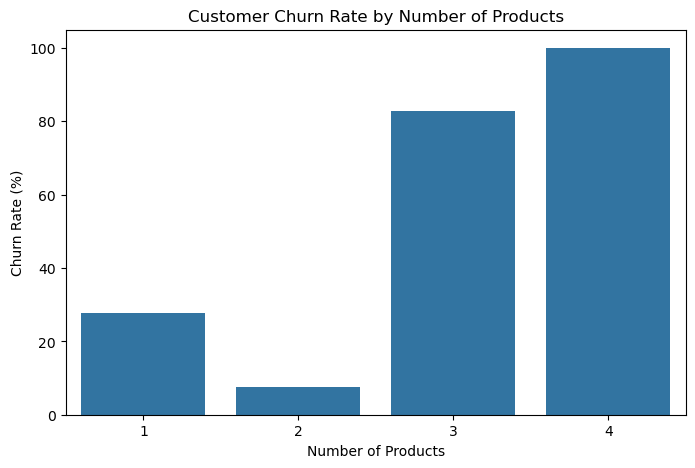

In [101]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=product_churn,
    x="NumOfProducts",
    y="churn_rate"
)

plt.title("Customer Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.show()

### Insight
Churn rates vary substantially across product-count segments,4 number of products is showing the highest churn rate. This suggests that the depth of a customer's product relationship may be associated with retention.

### Business Action
The bank should investigate high-churn product segments to determine whether customers have poor product fit, dissatisfaction, or unusual product combinations.

### Is credit score associated with customer churn?

In [104]:
churn_df["CreditScoreGroup"] = pd.cut(
    churn_df["CreditScore"],
    bins=[0, 499, 599, 699, 799, 900],
    labels=["<500", "500-599", "600-699", "700-799", "800+"]
)

credit_churn = (
    churn_df.groupby(
        "CreditScoreGroup",
        observed=True
    )["Exited"]
    .agg(["count", "mean"])
    .reset_index()
)

credit_churn["churn_rate"] = (
    credit_churn["mean"] * 100
)

credit_churn

,CreditScoreGroup,count,mean,churn_rate
0,<500,632,0.237342,23.734177
1,500-599,2402,0.212323,21.232306
2,600-699,3818,0.197224,19.722368
3,700-799,2493,0.198957,19.895708
4,800+,655,0.195420,19.541985


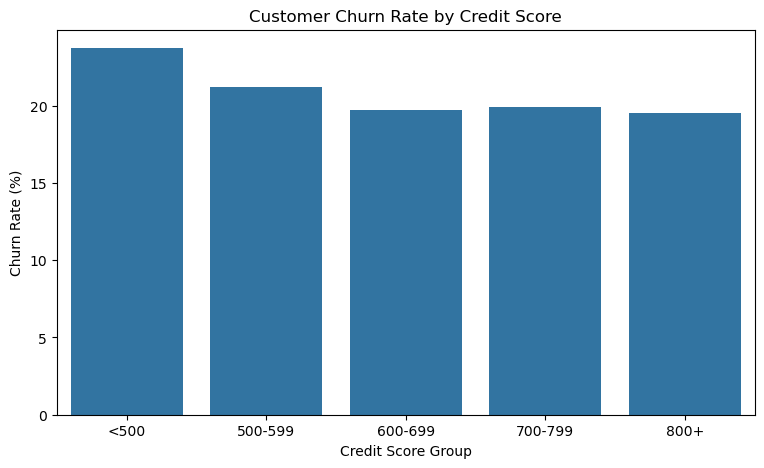

In [105]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=credit_churn,
    x="CreditScoreGroup",
    y="churn_rate"
)

plt.title("Customer Churn Rate by Credit Score")
plt.xlabel("Credit Score Group")
plt.ylabel("Churn Rate (%)")

plt.show()

### Insight
Churn rates differ across credit-score groups, with credit score below 500 showing the highest churn rate. This indicates that churn behavior is not uniform across customer credit profiles.

### Business Action
The bank should investigate the needs and product usage of high-churn credit-score segments and evaluate whether tailored products or service strategies could improve retention.

### Are customers with higher account balances more likely to churn?

In [108]:
balance_summary = (
    churn_df.groupby("Exited")["Balance"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

balance_summary["Customer_Status"] = (
    balance_summary["Exited"].map({
        0: "Retained",
        1: "Churned"
    })
)

balance_summary

,Exited,count,mean,median,Customer_Status
0,0,7963,72745.296779,92072.68,Retained
1,1,2037,91108.539337,109349.29,Churned


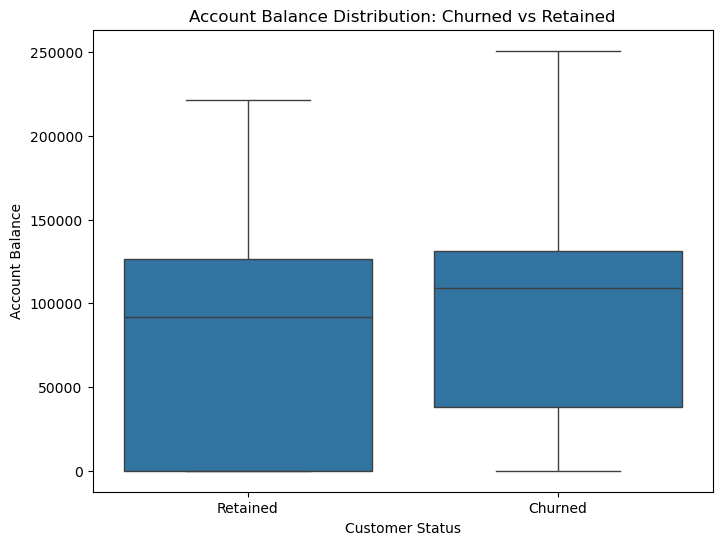

In [109]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=churn_df,
    x="Exited",
    y="Balance"
)

plt.title("Account Balance Distribution: Churned vs Retained")
plt.xlabel("Customer Status")
plt.ylabel("Account Balance")

plt.xticks(
    [0, 1],
    ["Retained", "Churned"]
)

plt.show()

### Insight 
Churned and retained customers show different account-balance distributions, indicating that account balance may be relevant when identifying customers who could have greater financial value at risk.

### Business Action
The bank should combine account balance with other churn indicators to prioritize retention efforts toward high-value customers who also show elevated churn risk.

### Which customer segments have the highest churn risk?

In [112]:
segment_analysis = (
    churn_df.groupby(
        [
            "Geography",
            "AgeGroup",
            "IsActiveMember",
            "NumOfProducts"
        ],
        observed=True
    )["Exited"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

segment_analysis["churn_rate"] = (
    segment_analysis["mean"] * 100
)

segment_analysis = (
    segment_analysis[
        segment_analysis["count"] >= 50
    ]
    .sort_values(
        "churn_rate",
        ascending=False
    )
)

segment_analysis.head(10)

,Geography,AgeGroup,IsActiveMember,NumOfProducts,count,sum,mean,churn_rate
53,Germany,50+,No,1,126,112,0.888889,88.888889
22,France,50+,No,1,148,129,0.871622,87.162162
82,Spain,50+,No,1,52,43,0.826923,82.692308
45,Germany,40-49,No,1,247,159,0.643725,64.372470
57,Germany,50+,Yes,1,130,66,0.507692,50.769231
49,Germany,40-49,Yes,1,156,74,0.474359,47.435897
75,Spain,40-49,No,1,180,79,0.438889,43.888889
14,France,40-49,No,1,352,149,0.423295,42.329545
37,Germany,30-39,No,1,254,80,0.314961,31.496063
26,France,50+,Yes,1,227,60,0.264317,26.431718


## Recommendations :
- Prioritize high-risk customers: Build a churn-risk customer list using the identified combinations of geography, age, activity, and product ownership, and proactively contact customers before they leave.
- Re-engage inactive customers: Launch personalized campaigns for inactive members through relationship-manager calls, targeted offers, digital notifications, and relevant banking-product recommendations to increase engagement.
- Strengthen market-specific retention: Investigate the highest-churn geography for differences in customer service, product satisfaction, pricing, and local competition, then design retention strategies specifically for that market.
- Improve product-fit and relationship depth: Review customers with unusually high churn across product groups and offer relevant products or relationship benefits based on their needs rather than using broad cross-selling campaigns.
- Protect high-value customers: Combine churn indicators with account balance to identify financially valuable customers at risk of leaving and provide proactive relationship-manager intervention, personalized service, and retention offers.